In [ ]:
# ==============================================================================
# CELDA 0: RUTAS DEL REPOSITORIO
# Este cuaderno leia sus datos desde Google Drive. Ahora los lee del propio
# repositorio, de modo que corre en cualquier clon sin configuracion previa.
# La raiz se resuelve buscando hacia arriba: funciona igual si el cuaderno se
# ejecuta desde su carpeta o desde la raiz del proyecto.
# ==============================================================================
from pathlib import Path

def _raiz_del_repositorio() -> Path:
    actual = Path.cwd().resolve()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / 'pyproject.toml').exists() and (carpeta / 'quanta').is_dir():
            return carpeta
    raise RuntimeError(
        'No se encontro la raiz del repositorio. Ejecute el cuaderno desde '
        'dentro del proyecto indice-sned.'
    )

RAIZ            = _raiz_del_repositorio()
RUTA_RAW        = (RAIZ / 'data' / 'raw').as_posix() + '/'
RUTA_PROCESADOS = (RAIZ / 'data' / 'processed').as_posix() + '/'
RUTA_REGISTRO   = (RAIZ / 'models' / 'registry').as_posix() + '/'
RUTA_METADATOS  = (RAIZ / 'models' / 'metadata').as_posix() + '/'

print('Raiz del repositorio:', RAIZ)


# **Bechmark Global**

## Decisiones para el modelo global (benchmark)

**Arquitecturas a comparar (las 3 que exige tu tesis):**

| # | Modelo | Justificación |
|---|---|---|
| 1 | **Random Forest** | Baseline robusto, ya validado en la Parte 1 |
| 2 | **HistGradientBoostingRegressor** | Informe 4 lo impone sobre `GradientBoostingRegressor`: binning en 255 bins, órdenes de magnitud más rápido a 23k filas, acepta NaN nativamente, early stopping interno |
| 3 | **MLP (Keras)** | Cumple el requisito de arquitectura de Deep Learning |

*Sobre XGBoost:* Géron apenas lo menciona (p.211). Si se instala, se agrega como cuarto modelo; si no, `HistGradientBoosting` es su equivalente funcional (misma familia, misma optimización por histogramas de LightGBM). Se documenta así en la tesis.

**Contradicciones entre informes, resueltas:**

1. **Salida del MLP — sigmoide×100 (informe 3) vs lineal (informe 4):** decido **salida lineal + clip a [0,100]**. La sigmoide satura el gradiente justo en los extremos, que es donde están los colegios en situación crítica y los de excelencia — precisamente los casos que más importan. El clip post-hoc consigue el acotamiento sin dañar el aprendizaje, y es coherente con lo que ya aplicamos en los 6 modelos por factor.

2. **Codificación de `CLUSTER` — one-hot (informe 3) vs embeddings (informe 3) vs target encoding:** decido **target encoding para las tres arquitecturas**. Razón: tus propias pruebas mostraron rendimiento equivalente al one-hot (R² 0,674 vs 0,676) con 121 columnas menos. Usar embeddings solo en el MLP rompería la comparación justa (features distintas por modelo). Los embeddings quedan documentados como trabajo futuro.

3. **Imputación — nativa de HistGB vs pipeline común:** decido **pipeline idéntico para las tres** (`SimpleImputer(median, add_indicator=True)`). Un benchmark exige que los tres modelos vean exactamente la misma matriz; si HistGB usara su manejo nativo tendría una ventaja de información que invalidaría la comparación.

**Configuración por arquitectura:**

- **RF:** `n_estimators` 300-800, `max_depth` 5-15/None, `min_samples_leaf` 10-40, `max_features` sqrt/log2/0.5
- **HistGB:** `learning_rate` 0,01-0,05, `max_iter` 500-1200, `max_depth` 3-5, `min_samples_leaf` 15-40, `l2_regularization`, `early_stopping=True`
- **MLP:** estrategia *stretch pants* (2-3 capas sobredimensionadas + regularización fuerte), Nadam, dropout 0,2-0,5, batch 32, `EarlyStopping(patience=8, restore_best_weights=True)`, `StandardScaler` obligatorio

**Protocolo de validación:**
- GroupKFold(5) por `rbd` en las tres
- **Bucle manual de folds para Keras** — el informe 4 documenta que `KerasRegressor` falla con `clone()` de scikit-learn
- Métricas por fold: RMSE, MAE, R²
- **Intervalos de confianza 95% con distribución t** sobre los 5 folds; si los IC no se solapan, la diferencia es estadísticamente significativa
- Curvas de aprendizaje (`history.history`) para diagnosticar sobreajuste del MLP

**Búsqueda de hiperparámetros:** `RandomizedSearchCV` con `n_iter=25` para los modelos de árboles; para el MLP, búsqueda reducida priorizando learning rate y arquitectura sobre parámetros secundarios (criterio del informe 4).

## Marco de decisiones metodológicas para el modelo global de referencia

*Fundamentación bibliográfica basada en Géron, A., "Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow"*

---

### 1. Propósito del artefacto y su relación con el motor del simulador

El notebook `BENCHMARK_GLOBAL.ipynb` cumple una función distinta y complementaria a la del motor de simulación ya construido. Mientras los seis modelos por factor se diseñaron bajo la restricción de que cada uno consumiera exclusivamente las variables que la normativa oficial declara como insumo de ese factor —restricción impuesta por el requerimiento de trazabilidad del simulador XAI—, el modelo global se libera de esa restricción para responder una pregunta puramente predictiva: **cuál es la mejor estimación alcanzable del INDICER cuando se permite al algoritmo utilizar la totalidad de la información disponible**.

Esta separación no es arbitraria. Géron distingue explícitamente entre el objetivo de predicción y el objetivo de comprensión del fenómeno (Cap. 1), señalando que un mismo conjunto de datos admite arquitecturas distintas según cuál de los dos propósitos predomine. El motor por factores privilegia la interpretabilidad causal; el modelo global privilegia la precisión. Reportar ambos, con sus métricas respectivas, constituye evidencia más completa que optar por uno solo.

Adicionalmente, el modelo global satisface el Objetivo Específico 3 de la investigación, que exige el entrenamiento y comparación de al menos tres arquitecturas distintas de aprendizaje automático.

---

### 2. Selección de arquitecturas a comparar

**Decisión: Random Forest, HistGradientBoostingRegressor y Perceptrón Multicapa (Keras).**

La justificación de fondo es el teorema de "No Free Lunch", que Géron introduce en el Capítulo 1: no existe un algoritmo universalmente superior, y toda afirmación sobre la superioridad de un modelo requiere evaluación empírica en el dominio específico. En consecuencia, la selección debe cubrir familias algorítmicas con supuestos inductivos diferentes, no variantes de una misma familia.

**Random Forest** se incorpora como representante de los métodos de *bagging* (Cap. 7, p. 195-199). Su mecanismo —promediar predictores entrenados sobre muestras bootstrap con selección aleatoria de características— reduce la varianza sin incrementar sustancialmente el sesgo. Géron destaca dos propiedades relevantes para este caso: su robustez ante escalas heterogéneas de las variables, que elimina la necesidad de normalización, y su resistencia al sobreajuste al aumentar el número de estimadores.

**HistGradientBoostingRegressor** se incorpora como representante del *boosting*, reemplazando al `GradientBoostingRegressor` estándar. La justificación es de eficiencia computacional: la implementación basada en histogramas discretiza las variables continuas en un número acotado de contenedores (típicamente 255), reduciendo drásticamente el costo de evaluar puntos de corte candidatos en cada nodo (Cap. 7). A la escala de 23.111 registros, esta optimización permite explorar un espacio de hiperparámetros considerablemente más amplio dentro del mismo presupuesto de tiempo. La diferencia conceptual con el bagging es sustantiva: mientras Random Forest promedia predictores independientes para reducir varianza, el boosting construye predictores secuencialmente donde cada árbol se ajusta a los residuos del ensamble previo, reduciendo el sesgo de manera aditiva (Cap. 7, p. 205).

**Perceptrón Multicapa** se incorpora como representante del aprendizaje profundo (Cap. 10). Su inclusión responde tanto al requerimiento formal de la investigación como a una pregunta legítima: determinar si la capacidad de las redes neuronales para aprender representaciones internas y capturar interacciones de alto orden aporta ventaja sobre los métodos de ensamble en un problema tabular de esta escala.

**Arquitecturas descartadas y su fundamento.** Se excluyen las redes convolucionales (Cap. 14) y recurrentes (Cap. 15) porque sus supuestos inductivos —invarianza traslacional en estructuras espaciales y dependencia secuencial, respectivamente— no corresponden a la estructura de los datos. Incorporarlas violaría el principio de parsimonia sin expectativa razonable de mejora. Se excluye asimismo el *stacking* (Cap. 7, p. 210): aunque técnicamente aplicable, su función es aprender la combinación óptima de predictores base, y en este problema la combinación de los seis factores está determinada por una fórmula legal conocida y verificada empíricamente con R² = 1,0000, por lo que un meta-modelo no tendría nada que aprender.

**Respecto de XGBoost.** La investigación declara XGBoost entre las arquitecturas a evaluar. Géron lo menciona brevemente en el Capítulo 7, sin desarrollar su configuración con la profundidad que dedica a las implementaciones nativas de scikit-learn. Se adopta el siguiente criterio: si la biblioteca está disponible en el entorno de ejecución, se incorpora como cuarta arquitectura con `early_stopping_rounds` en el método de ajuste; en caso contrario, `HistGradientBoostingRegressor` opera como su equivalente funcional, dado que ambas implementan boosting por histogramas con regularización explícita. Esta equivalencia se documenta como decisión metodológica, no como omisión.

---

### 3. Tratamiento de la variable categórica de alta cardinalidad

**Decisión: target encoding con validación cruzada interna, aplicado uniformemente a las tres arquitecturas.**

La variable `CLUSTER` presenta aproximadamente 138 niveles. Géron discute dos estrategias en el Capítulo 13: la codificación one-hot (p. 422) y los embeddings aprendidos (p. 423), señalando que la primera resulta ineficiente cuando la cardinalidad es elevada, porque genera matrices dispersas de alta dimensionalidad, y que la segunda permite mapear las categorías a un espacio vectorial denso de baja dimensión donde categorías semánticamente próximas quedan próximas geométricamente.

La regla heurística que el texto propone para dimensionar el embedding sugiere una dimensión cercana a la raíz cuarta del número de categorías, lo que para 138 niveles arroja aproximadamente 3,4, es decir, una dimensión de 4.

Sin embargo, se adopta el target encoding por dos razones. La primera es empírica: en las pruebas exploratorias realizadas sobre este mismo conjunto de datos, la codificación one-hot y el target encoding produjeron desempeños prácticamente indistinguibles (R² de 0,674 frente a 0,676), pero el segundo redujo la matriz de 141 a 20 columnas. La ganancia en parsimonia fue sustancial y la pérdida predictiva, nula.

La segunda razón es metodológica y de mayor peso: un experimento comparativo exige que todas las arquitecturas reciban exactamente la misma representación de entrada. Emplear embeddings únicamente en la red neuronal —única arquitectura que los admite de forma nativa— introduciría una diferencia de representación que se confundiría con la diferencia de arquitectura, invalidando la atribución causal de cualquier diferencia observada en el desempeño. La comparación dejaría de responder "qué arquitectura es superior" para responder "qué combinación de arquitectura y codificación es superior", pregunta distinta y de conclusión ambigua.

Para prevenir la fuga de información inherente al target encoding —el riesgo de que la codificación de una observación incorpore información de su propia variable objetivo— se implementa mediante validación cruzada interna: la media de cada categoría se calcula excluyendo el pliegue en que la observación será codificada.

Los embeddings se documentan como línea de trabajo futuro.

---

### 4. Tratamiento de valores faltantes con significado semántico

**Decisión: imputación por mediana acompañada de variable indicadora binaria (`add_indicator=True`), uniforme para las tres arquitecturas.**

Los valores faltantes de este conjunto de datos no constituyen error de registro sino información sustantiva: la ausencia de un puntaje SIMCE en un nivel determinado significa que el establecimiento no imparte ese nivel educativo. Se trata, en la terminología estándar, de datos MNAR (*Missing Not At Random*), donde el mecanismo de ausencia está correlacionado con características del propio establecimiento.

Géron advierte en el Capítulo 2 que la ausencia de datos no debe tratarse mecánicamente como un defecto a corregir, sino evaluarse como potencial señal informativa. La estrategia de imputación acompañada de indicador binario preserva ambas dimensiones: la imputación permite que el algoritmo procese la observación completa, mientras que el indicador conserva explícitamente la información de que el dato estaba ausente, permitiendo al modelo aprender si esa ausencia es en sí misma predictiva.

Se descarta la imputación iterativa multivariada. Aunque técnicamente más sofisticada, reconstruiría un puntaje SIMCE plausible para un nivel educativo que el establecimiento no imparte, generando un valor que no solo es desconocido sino que carece de referente empírico posible.

Respecto de la uniformidad: `HistGradientBoostingRegressor` admite valores nulos de forma nativa, decidiendo en cada nodo la dirección de ramificación de las observaciones faltantes según la reducción de impureza. Esta capacidad constituye una ventaja algorítmica genuina. No obstante, se opta por aplicar el mismo pipeline de imputación a las tres arquitecturas, por la misma razón expuesta en la sección anterior: si una arquitectura procesara una representación distinta de los datos, la comparación perdería validez interna. La capacidad nativa se documenta y se propone como configuración recomendada para el despliegue en producción, una vez concluida la fase comparativa.

---

### 5. Escalamiento diferencial de características

**Decisión: `StandardScaler` obligatorio para el MLP, omitido en las arquitecturas basadas en árboles.**

Esta es la única asimetría de preprocesamiento que se admite entre arquitecturas, y su justificación es que no constituye una elección metodológica sino un requisito algorítmico.

Los modelos basados en árboles particionan el espacio de características mediante umbrales sobre variables individuales; una transformación monótona de una variable no altera el orden de sus valores y, por tanto, no modifica los puntos de corte candidatos ni la estructura del árbol resultante. El escalamiento es, para ellos, computacionalmente inocuo e irrelevante.

Las redes neuronales, en cambio, dependen del descenso de gradiente, y Géron es enfático al señalar su sensibilidad a la escala de las entradas (Cap. 10-11). Con características en escalas heterogéneas —en este conjunto conviven puntajes SIMCE en el orden de las centenas, tasas de aprobación entre 0 y 1, y conteos de sanciones entre 0 y 14— la superficie de pérdida adopta una geometría alargada donde el gradiente oscila en las direcciones de mayor escala y avanza lentamente en las restantes, retardando o impidiendo la convergencia.

El escalador se ajusta exclusivamente sobre el pliegue de entrenamiento en cada iteración de la validación cruzada, aplicándose por transformación al pliegue de validación, conforme al protocolo de prevención de *data snooping* que el texto establece en el Capítulo 2.

---

### 6. Acotamiento del rango de predicción

**Decisión: activación lineal en la capa de salida del MLP, con recorte posterior de las predicciones al intervalo [0, 100] en las tres arquitecturas.**

Este punto exigió resolver una contradicción entre los informes técnicos consultados. Una alternativa propuesta consistía en emplear activación sigmoide en la capa de salida multiplicada por 100, lo que garantizaría por construcción que ninguna predicción excediera el rango válido.

Se descarta esa opción. Géron advierte en el Capítulo 11 sobre el problema de saturación de las funciones de activación de tipo sigmoide: su derivada tiende a cero conforme el argumento se aleja del origen, de modo que las neuronas que operan en las colas de la función dejan de propagar gradiente efectivo y su aprendizaje se estanca. Este fenómeno —el mismo que motivó históricamente el reemplazo de la sigmoide por ReLU en las capas ocultas— resultaría particularmente dañino en este problema, porque las regiones de saturación coinciden exactamente con los establecimientos de desempeño extremo: aquellos en situación crítica y aquellos de excelencia. Son precisamente los casos de mayor interés sustantivo para la investigación y para el usuario final del simulador.

La activación lineal preserva un gradiente constante en todo el dominio, permitiendo que la red aprenda con igual eficacia en los extremos y en el centro de la distribución. El recorte posterior de predicciones garantiza la validez del rango sin interferir con el proceso de optimización. Esta decisión mantiene además coherencia con el tratamiento ya aplicado a los seis modelos por factor del motor de simulación.

---

### 7. Arquitectura y regularización de la red neuronal

**Decisión: estrategia de sobredimensionamiento con regularización fuerte, dos a tres capas ocultas.**

Géron propone en el Capítulo 10 (p. 319-320) una heurística que denomina informalmente "pantalones elásticos": en lugar de invertir recursos computacionales en identificar el tamaño exacto óptimo de la red, resulta más eficiente construir una arquitectura con capacidad excedente y controlar el sobreajuste mediante regularización. El argumento es de economía experimental: el espacio de configuraciones arquitectónicas es vasto, mientras que los mecanismos de regularización son pocos y bien comprendidos.

Se adopta esta estrategia con dos a tres capas ocultas, rango que el texto sugiere como punto de partida razonable para problemas tabulares antes de escalar en profundidad.

El conjunto de mecanismos de regularización aplicados comprende:

**Dropout** (Cap. 11, p. 357), con tasas en el rango de 0,2 a 0,5. El mecanismo desactiva aleatoriamente un subconjunto de neuronas en cada paso de entrenamiento, forzando a la red a distribuir la representación en múltiples rutas en lugar de concentrarla en unidades específicas, lo que induce redundancia y mejora la generalización.

**Regularización sobre los pesos**, mediante penalizaciones ℓ₁ y ℓ₂ aplicadas a las capas densas (Cap. 11, p. 356), y opcionalmente restricción de norma máxima (p. 362), que acota la magnitud del vector de pesos entrante a cada neurona.

**Detención temprana** (Cap. 4 y Cap. 10), que el texto califica como una de las técnicas de regularización más elegantes por su simplicidad y efectividad. Se configura un techo elevado de épocas y se delega el control efectivo al *callback*, con paciencia entre 5 y 10 épocas y restauración de los mejores pesos activada. Esta última opción es crítica: sin ella, el modelo final conservaría los pesos de la última época ejecutada, que por definición corresponden a un estado posterior al punto de mínimo error de validación.

**Tamaño de lote de 32 observaciones.** Géron discute en el Capítulo 11 el compromiso entre lotes grandes —que aprovechan mejor la paralelización del hardware— y lotes pequeños, que introducen ruido estocástico en la estimación del gradiente. Ese ruido opera como regularizador implícito y favorece la convergencia hacia mínimos de curvatura suave, que generalizan mejor que los mínimos agudos hacia los que tienden los lotes grandes.

---

### 8. Optimizador y calendarización de la tasa de aprendizaje

**Decisión: Nadam con calendarización exponencial, precedido de una búsqueda exploratoria de la tasa de aprendizaje inicial.**

El Capítulo 11 (p. 344) presenta una progresión de optimizadores de creciente sofisticación sobre el descenso de gradiente estocástico básico: momento clásico, momento de Nesterov, AdaGrad, RMSProp, Adam y Nadam. Este último combina la estimación adaptativa de momentos de Adam con la corrección anticipatoria de Nesterov, evaluando el gradiente en la posición proyectada del siguiente paso en lugar de la actual.

Géron identifica la tasa de aprendizaje como el hiperparámetro individual de mayor impacto sobre la convergencia (Cap. 10, p. 320), y propone un procedimiento sistemático para determinarla: entrenar durante una época incrementando la tasa exponencialmente en cada iteración, graficar la pérdida contra la tasa, e identificar el punto donde la pérdida comienza a divergir. La tasa óptima se sitúa aproximadamente un orden de magnitud por debajo de ese punto de inflexión.

Se complementa con calendarización exponencial (Cap. 11, p. 352), que reduce progresivamente la tasa conforme avanza el entrenamiento, permitiendo exploración amplia en las fases iniciales y refinamiento fino en la convergencia final.

Se evalúa como configuración alternativa la combinación de activación SELU con inicialización LeCun Normal (Cap. 11), que confiere a la red la propiedad de auto-normalización: bajo condiciones específicas, las activaciones preservan media cero y varianza unitaria a través de las capas, lo que hace innecesaria la normalización por lotes.

---

### 9. Esquema de validación

**Decisión: GroupKFold de cinco pliegues agrupado por identificador de establecimiento, con bucle manual de pliegues para la red neuronal.**

La estructura longitudinal del conjunto de datos —7.754 establecimientos observados en tres ciclos, compartiendo idénticas variables predictoras— viola el supuesto de independencia entre observaciones. Una validación cruzada con asignación aleatoria por fila colocaría registros del mismo establecimiento simultáneamente en entrenamiento y validación, permitiendo al modelo memorizar establecimientos concretos en lugar de aprender relaciones generalizables. La métrica resultante sería optimista y no informaría sobre el desempeño esperado ante establecimientos no vistos, que es la condición real de uso del sistema.

`GroupKFold` garantiza que la totalidad de los registros de un establecimiento permanezca en un único pliegue.

Para las arquitecturas basadas en árboles, la integración con `RandomizedSearchCV` es directa. Para la red neuronal se implementa un bucle manual sobre los pliegues, decisión fundamentada en las limitaciones que Géron documenta respecto de los envoltorios de Keras para scikit-learn (Cap. 10, p. 315): incompatibilidad con el mecanismo de clonación de estimadores y propagación defectuosa de ciertos hiperparámetros hacia la función constructora del modelo. El bucle manual —iterar sobre las particiones, segmentar los datos, ajustar, evaluar y promediar— evita ambos problemas a costa de mayor verbosidad en el código.

---

### 10. Búsqueda de hiperparámetros y presupuesto computacional

**Decisión: `RandomizedSearchCV` con 25 iteraciones para las arquitecturas de árboles; búsqueda reducida y priorizada para la red neuronal.**

Géron argumenta en el Capítulo 2 la superioridad de la búsqueda aleatoria sobre la búsqueda exhaustiva en rejilla cuando el espacio de hiperparámetros es amplio: con un presupuesto fijo de *n* evaluaciones, la búsqueda aleatoria explora *n* valores distintos de cada hiperparámetro, mientras que la rejilla explora únicamente los pocos valores predefinidos manualmente. Dado que la importancia relativa de los hiperparámetros es habitualmente muy desigual, muestrear ampliamente el espacio resulta más eficiente que enrejar exhaustivamente un subconjunto arbitrario.

El texto recomienda además fijar el número de iteraciones en función del presupuesto de tiempo disponible, no de un criterio teórico. La ejecución previa del motor por factores estableció una referencia empírica útil: seis búsquedas de 25 iteraciones sobre este mismo conjunto de datos requirieron aproximadamente 2,7 horas.

Para la red neuronal, cuyo costo de entrenamiento por configuración es sustancialmente superior, se reduce el número de configuraciones evaluadas y se prioriza la exploración de la tasa de aprendizaje y la arquitectura por sobre los parámetros secundarios de regularización, siguiendo el orden de importancia que el texto establece.

**Grillas de búsqueda:**

Random Forest: número de estimadores entre 300 y 800, profundidad máxima entre 5 y 15 o sin límite, mínimo de muestras por hoja entre 10 y 40, y número de características por división en las variantes raíz cuadrada, logaritmo base dos o cincuenta por ciento del total (Cap. 6, p. 184; Cap. 7, p. 199).

HistGradientBoosting: tasa de aprendizaje entre 0,01 y 0,05, iteraciones máximas entre 500 y 1.200, profundidad entre 3 y 5, mínimo de muestras por hoja entre 15 y 40, y regularización ℓ₂. Géron señala la relación inversa entre tasa de aprendizaje y número de estimadores (Cap. 7, p. 205): tasas menores requieren más árboles pero producen ensambles que generalizan mejor.

---

### 11. Métricas de evaluación e inferencia estadística

**Decisión: reporte conjunto de RMSE, MAE y R² por pliegue, con intervalos de confianza al 95% construidos sobre la distribución t de Student.**

Géron discute en el Capítulo 2 la elección entre la raíz del error cuadrático medio y el error absoluto medio, correspondientes a las normas ℓ₂ y ℓ₁ respectivamente. La primera penaliza cuadráticamente las desviaciones grandes, resultando más sensible a observaciones atípicas; la segunda pondera todos los errores linealmente. Se reportan ambas: el RMSE como métrica principal de comparación y el MAE como métrica de interpretación sustantiva, dado que expresa el error esperado en las unidades del índice.

La afirmación de superioridad de una arquitectura sobre otra requiere sustento inferencial. Se calcula el intervalo de confianza al 95% sobre la métrica de error a partir de la dispersión entre los cinco pliegues, empleando la distribución t de Student en lugar de la normal, dado que la varianza poblacional se estima a partir de una muestra reducida. El criterio de decisión es el solapamiento de intervalos: únicamente cuando los intervalos de dos arquitecturas no se solapan se declara la diferencia estadísticamente significativa. En caso de solapamiento, se concluye equivalencia estadística y la elección entre modelos se resuelve por criterios secundarios —costo computacional, interpretabilidad o simplicidad de despliegue.

Este criterio protege contra la sobreinterpretación de diferencias marginales, riesgo particularmente relevante cuando se comparan arquitecturas cuyo desempeño esperado es próximo.

---

### 12. Diagnóstico de sesgo y varianza

**Decisión: construcción de curvas de aprendizaje para todas las arquitecturas y análisis del historial de entrenamiento para la red neuronal.**

Géron presenta las curvas de aprendizaje en el Capítulo 4 (p. 132) como el instrumento diagnóstico para discriminar entre las dos patologías fundamentales del ajuste. El procedimiento consiste en graficar el error de entrenamiento y el error de validación en función del tamaño creciente del conjunto de entrenamiento.

La convergencia de ambas curvas hacia un valor de error elevado indica subajuste, es decir, sesgo alto: el modelo carece de capacidad para representar la estructura de los datos. En esta situación, incrementar el volumen de datos no produce mejora; la acción correctiva pasa por aumentar la complejidad del modelo o enriquecer el conjunto de características.

La persistencia de una brecha amplia entre ambas curvas, con error de entrenamiento sustancialmente inferior al de validación, indica sobreajuste, esto es, varianza alta: el modelo memoriza el ruido específico de la muestra de entrenamiento. La acción correctiva consiste en intensificar la regularización, simplificar la arquitectura o incrementar el volumen de datos.

Para la red neuronal, el objeto de historial que Keras retorna tras el ajuste permite un diagnóstico equivalente en función de las épocas transcurridas (Cap. 10). El patrón de alerta es el momento en que la pérdida de validación deja de descender mientras la de entrenamiento continúa haciéndolo, punto que marca el inicio del sobreajuste y que la detención temprana debe identificar automáticamente.

---

### 13. Síntesis de configuración

| Dimensión | Random Forest | HistGradientBoosting | MLP (Keras) |
|---|---|---|---|
| Familia algorítmica | Bagging | Boosting | Red neuronal densa |
| Referencia | Cap. 7, p. 195-200 | Cap. 7, p. 205-210 | Cap. 10-11 |
| Escalamiento | No requerido | No requerido | StandardScaler obligatorio |
| Codificación de CLUSTER | Target encoding | Target encoding | Target encoding |
| Valores faltantes | Mediana + indicador | Mediana + indicador | Mediana + indicador |
| Acotamiento del rango | Recorte posterior | Recorte posterior | Salida lineal + recorte |
| Regularización principal | Profundidad, hojas mínimas | Tasa de aprendizaje, ℓ₂, detención temprana | Dropout, ℓ₁/ℓ₂, detención temprana |
| Validación | GroupKFold(5) | GroupKFold(5) | GroupKFold(5), bucle manual |
| Búsqueda | RandomizedSearchCV, 25 iter. | RandomizedSearchCV, 25 iter. | Búsqueda reducida priorizada |

---

### 14. Limitaciones declaradas del diseño experimental

La honestidad metodológica exige explicitar las restricciones que este diseño asume.

Primero, la uniformización del preprocesamiento entre arquitecturas —adoptada para preservar la validez interna de la comparación— impide que `HistGradientBoostingRegressor` explote su manejo nativo de valores nulos, capacidad que constituye una ventaja genuina en condiciones de despliegue. El desempeño reportado para esa arquitectura debe entenderse, en consecuencia, como una cota inferior de su potencial real.

Segundo, la decisión de emplear target encoding en lugar de embeddings para la variable categórica de alta cardinalidad restringe deliberadamente la capacidad de la red neuronal de aprender representaciones latentes de los grupos homogéneos, que es una de sus ventajas distintivas frente a los métodos de ensamble. La comparación resultante es justa en términos de información disponible, pero conservadora respecto del potencial de la arquitectura profunda.

Tercero, el volumen de 23.111 observaciones se sitúa por debajo del rango donde la literatura documenta ventajas consistentes del aprendizaje profundo sobre los ensambles de árboles en datos tabulares. Un resultado desfavorable para la red neuronal debe interpretarse, por tanto, como propiedad del régimen de datos y no como refutación general de la arquitectura.

Cuarto, la estructura longitudinal se aborda mediante agrupación en la validación, lo que previene la fuga de información pero no modela explícitamente la dependencia temporal entre los tres ciclos observados de cada establecimiento. Un tratamiento formal de esa estructura —mediante modelos de efectos mixtos o arquitecturas secuenciales— excede el alcance de esta investigación y se propone como extensión futura.

In [1]:
# ==============================================================================
# CELDA 1: CARGA DE DATOS Y CONSTRUCCIÓN DE LA MATRIZ GLOBAL DE FEATURES
# ==============================================================================
# Objetivo: predecir INDICER usando TODAS las variables disponibles.
# A diferencia del motor por factores, aquí no hay restricción de trazabilidad:
# el modelo puede usar cualquier variable que no constituya fuga de información.
# ==============================================================================
import pandas as pd
import numpy as np

RUTA = RUTA_PROCESADOS
df = pd.read_parquet(RUTA + 'tabla_modelo_largo.parquet')

print(f"Tabla larga: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Establecimientos únicos: {df['rbd'].nunique()} | Ciclos: {sorted(df['BIENIO_PREMIO'].unique())}")

# ==============================================================================
# 1. INCORPORAR DIFERENCIAS SIMCE (mismo insumo que mejoró el factor Superación)
# ==============================================================================
df_simce = pd.read_parquet(RUTA + 'simce_maestro_bienios.parquet')
cols_simce = ['simce_lect_4b','simce_mate_4b','simce_lect_6b','simce_mate_6b',
              'simce_lect_8b','simce_mate_8b','simce_lect_2m','simce_mate_2m']

s_prev = df_simce[df_simce['BIENIO']=='2016-17'][['rbd']+cols_simce].rename(
    columns={c: f'{c}_prev' for c in cols_simce})
s_act = df_simce[df_simce['BIENIO']=='2018-19'][['rbd']+cols_simce]

dif = pd.merge(s_act, s_prev, on='rbd', how='inner')
for c in cols_simce:
    dif[f'dif_{c}'] = dif[c] - dif[f'{c}_prev']
cols_dif = [f'dif_{c}' for c in cols_simce]

df = pd.merge(df, dif[['rbd'] + cols_dif], on='rbd', how='left')
print(f"\nDiferencias SIMCE incorporadas | filas con dato: {df['dif_simce_lect_4b'].notna().sum()}/{len(df)}")

# ==============================================================================
# 2. EXCLUSIONES POR FUGA DE INFORMACIÓN
# ==============================================================================
# Los 6 factores son los sumandos de INDICER (verificado: R²=1.0000 con la fórmula).
# Usarlos como predictores sería reconstruir el target desde sus propias partes.
FACTORES = ['EFECTIVR','SUPERAR','INICIAR','MEJORAR','INTEGRAR','IGUALDR']
TARGETS  = ['INDICER','SEL']
IDENTIFICADORES = ['rbd','nom_rbd','NOM_RBD']

excluir = FACTORES + TARGETS + IDENTIFICADORES
excluir = [c for c in excluir if c in df.columns]

print(f"\n--- Columnas excluidas ---")
print(f"Factores (fuga)   : {[c for c in FACTORES if c in df.columns]}")
print(f"Targets           : {[c for c in TARGETS if c in df.columns]}")
print(f"Identificadores   : {[c for c in IDENTIFICADORES if c in df.columns]}")

# ==============================================================================
# 3. SEPARACIÓN DE FEATURES POR TIPO
# ==============================================================================
candidatas = [c for c in df.columns if c not in excluir]

CATEGORICAS_ALTA_CARD = ['CLUSTER']                       # ~138 niveles -> target encoding
CATEGORICAS_BAJA_CARD = [c for c in ['cod_depe2','BIENIO_PREMIO'] if c in df.columns]
BOOLEANAS = [c for c in ['ES_RURAL','tiene_convenio_sep'] if c in df.columns]

NUMERICAS = [c for c in candidatas
             if c not in CATEGORICAS_ALTA_CARD + CATEGORICAS_BAJA_CARD + BOOLEANAS
             and pd.api.types.is_numeric_dtype(df[c])]

print(f"\n--- Tipología de features ---")
print(f"Numéricas              : {len(NUMERICAS)}")
print(f"Categóricas alta card. : {CATEGORICAS_ALTA_CARD} ({df['CLUSTER'].nunique()} niveles)")
print(f"Categóricas baja card. : {CATEGORICAS_BAJA_CARD}")
print(f"Booleanas              : {BOOLEANAS}")

# Verificación de que ninguna columna quedó sin clasificar
sin_clasificar = [c for c in candidatas
                  if c not in NUMERICAS + CATEGORICAS_ALTA_CARD + CATEGORICAS_BAJA_CARD + BOOLEANAS]
if sin_clasificar:
    print(f"\nAVISO | Columnas sin clasificar: {sin_clasificar}")

# ==============================================================================
# 4. DIAGNÓSTICO DE VALORES FALTANTES (MNAR)
# ==============================================================================
nulos = df[NUMERICAS].isnull().mean().sort_values(ascending=False)
con_nulos = nulos[nulos > 0]

print(f"\n--- Valores faltantes: {len(con_nulos)} de {len(NUMERICAS)} variables numéricas ---")
print((con_nulos.head(12) * 100).round(1).to_string())
print("\nEstos faltantes son MNAR: la ausencia indica que el establecimiento no")
print("imparte ese nivel educativo. Se tratan con mediana + indicador binario.")

# ==============================================================================
# 5. VARIABLE OBJETIVO
# ==============================================================================
y = df['INDICER'].copy()
grupos = df['rbd'].copy()

print(f"\n--- Variable objetivo (INDICER) ---")
print(f"n={len(y)} | media={y.mean():.2f} | std={y.std():.2f} | "
      f"rango=[{y.min():.1f}, {y.max():.1f}] | nulos={y.isnull().sum()}")
print(f"Grupos para validación (establecimientos): {grupos.nunique()}")

# Guardamos la configuración para las celdas siguientes
CONFIG = {
    'NUMERICAS': NUMERICAS,
    'CATEGORICAS_ALTA_CARD': CATEGORICAS_ALTA_CARD,
    'CATEGORICAS_BAJA_CARD': CATEGORICAS_BAJA_CARD,
    'BOOLEANAS': BOOLEANAS,
    'TARGET': 'INDICER',
    'GRUPO': 'rbd',
}
print(f"\nTotal de features candidatas: "
      f"{len(NUMERICAS) + len(CATEGORICAS_ALTA_CARD) + len(CATEGORICAS_BAJA_CARD) + len(BOOLEANAS)}")

Mounted at /content/drive
Tabla larga: 23111 filas x 68 columnas
Establecimientos únicos: 7754 | Ciclos: ['2020-21', '2022-23', '2024-25']

Diferencias SIMCE incorporadas | filas con dato: 18044/23111

--- Columnas excluidas ---
Factores (fuga)   : ['EFECTIVR', 'SUPERAR', 'INICIAR', 'MEJORAR', 'INTEGRAR', 'IGUALDR']
Targets           : ['INDICER', 'SEL']
Identificadores   : ['rbd', 'nom_rbd', 'NOM_RBD']

--- Tipología de features ---
Numéricas              : 60
Categóricas alta card. : ['CLUSTER'] (124 niveles)
Categóricas baja card. : ['cod_depe2', 'BIENIO_PREMIO']
Booleanas              : ['ES_RURAL', 'tiene_convenio_sep']

--- Valores faltantes: 37 de 60 variables numéricas ---
dif_simce_mate_2m    69.1
dif_simce_lect_2m    69.1
idps_cc_2m           68.9
simce_mate_2m        68.7
idps_pf_2m           68.7
idps_hv_2m           68.7
idps_am_2m           68.7
simce_lect_2m        68.7
ive_media            68.2
dif_simce_lect_8b    31.9
dif_simce_mate_8b    31.9
simce_mate_8b        30.

**Se predice (target): `INDICER`** — un solo valor continuo, 0-100.

`SEL` queda excluida de las features (sería fuga: se deriva del propio INDICER ordenado dentro del cluster). Puede modelarse aparte como clasificación en otra etapa.

**Se usan para predecir: 65 columnas**, agrupadas por fuente:

| Fuente | N° | Columnas |
|---|---|---|
| **SIMCE nivel** | 9 | `simce_lect/mate` × 4b, 6b, 8b, 2m + `simce_prom_4b` |
| **SIMCE diferencias** | 8 | `dif_simce_lect/mate` × 4 niveles (2018-19 vs 2016-17) |
| **IDPS** | 16 | `idps_am/cc/pf/hv` × 4b, 6b, 8b, 2m |
| **Denuncias** | 4 | total, fiscalización, jurídica, ciberbullying |
| **Procesos admin.** | 4 | total, con_sanción, multa, privación_subvención |
| **Mediaciones** | 3 | total, efectivas, de_denuncia |
| **Rendimiento** | 4 | `total_matricula`, tasa_aprobación, tasa_reprobación, tasa_retiro |
| **Matrícula** | 2 | `matricula_total`, `cursos_total` |
| **SEP** | 3 | n_vulnerables, n_beneficiarios_sep, tiene_convenio_sep |
| **Personal** | 4 | n_docentes, horas_docentes, n_directivos, n_asistentes |
| **IVE** | 3 | ive_basica, ive_media, ive_consolidado |
| **Contexto** | 5 | `CLUSTER`, `cod_depe2`, `BIENIO_PREMIO`, `ES_RURAL`, `ficha_no_respondida` |

**Se excluyen (11):**
- **Los 6 factores** (`EFECTIVR`, `SUPERAR`, `INICIAR`, `MEJORAR`, `INTEGRAR`, `IGUALDR`) → son los sumandos de INDICER, usarlos sería reconstruir el target desde sus partes.
- **`SEL`** → derivada del target.
- **`rbd`, `nom_rbd`, `NOM_RBD`** → identificadores, sin valor predictivo (y `rbd` se reserva para agrupar en la validación).

**Dato relevante de la salida:** `CLUSTER` tiene **124 niveles** (no 138 como asumían los informes) — igual es alta cardinalidad, la decisión de target encoding se mantiene.

¿Sigo con la Celda 2 (pipeline de preprocesamiento compartido)?

In [2]:
# ==============================================================================
# CELDA 2: PIPELINE DE PREPROCESAMIENTO COMPARTIDO
# ==============================================================================
# Criterio de validez interna: las tres arquitecturas reciben EXACTAMENTE la misma
# matriz de entrada. La única asimetría admitida es el escalado (requisito
# algorítmico del MLP, irrelevante para árboles).
#
# Todas las transformaciones se ajustan SOLO con el pliegue de entrenamiento
# (Cap. 2, prevención de data snooping).
# ==============================================================================
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print(f"scikit-learn versión: {sklearn.__version__}")

# --- Target encoding para CLUSTER (124 niveles) ---
# TargetEncoder de sklearn (>=1.3) aplica cross-fitting interno: la codificación
# de cada fila se calcula excluyendo su propio pliegue, evitando fuga.
try:
    from sklearn.preprocessing import TargetEncoder
    encoder_alta_card = TargetEncoder(target_type='continuous', cv=5, random_state=42)
    USA_TARGET_ENCODER = True
    print("TargetEncoder nativo disponible (cross-fitting interno)")
except ImportError:
    from sklearn.preprocessing import OrdinalEncoder
    encoder_alta_card = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    USA_TARGET_ENCODER = False
    print("AVISO: TargetEncoder no disponible -> se usa OrdinalEncoder como respaldo")

NUMERICAS = CONFIG['NUMERICAS']
CAT_ALTA = CONFIG['CATEGORICAS_ALTA_CARD']
CAT_BAJA = CONFIG['CATEGORICAS_BAJA_CARD']
BOOLEANAS = CONFIG['BOOLEANAS']

# --- Rama numérica: mediana + indicador binario de ausencia (MNAR, Cap. 2) ---
rama_numerica = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
])

# --- Rama categórica de baja cardinalidad: one-hot ---
rama_cat_baja = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first',
                             sparse_output=False)),
])

# --- Rama categórica de alta cardinalidad: target encoding ---
rama_cat_alta = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', encoder_alta_card),
])

# --- Rama booleana: a entero ---
rama_bool = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

def construir_preprocesador(escalar=False):
    """
    escalar=False -> árboles (RF, HistGB): sin escalado, es irrelevante
    escalar=True  -> MLP: StandardScaler obligatorio (Cap. 10-11)
    """
    ct = ColumnTransformer(
        transformers=[
            ('num',  rama_numerica,  NUMERICAS),
            ('cat_alta', rama_cat_alta, CAT_ALTA),
            ('cat_baja', rama_cat_baja, CAT_BAJA),
            ('bool', rama_bool, BOOLEANAS),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )
    pasos = [('preproc', ct)]
    if escalar:
        pasos.append(('scaler', StandardScaler()))
    return Pipeline(pasos)

# ==============================================================================
# VERIFICACIÓN: dimensión resultante de la matriz transformada
# ==============================================================================
COLS_ENTRADA = NUMERICAS + CAT_ALTA + CAT_BAJA + BOOLEANAS
X = df[COLS_ENTRADA].copy()

# Las categóricas deben ser string para los encoders
for c in CAT_ALTA + CAT_BAJA:
    X[c] = X[c].astype(str)
for c in BOOLEANAS:
    X[c] = X[c].astype(float)

prep_prueba = construir_preprocesador(escalar=False)
X_transformada = prep_prueba.fit_transform(X, y)

print(f"\n--- Matriz transformada ---")
print(f"Entrada : {X.shape[0]} filas x {X.shape[1]} columnas")
print(f"Salida  : {X_transformada.shape[0]} filas x {X_transformada.shape[1]} columnas")
print(f"Expansión: +{X_transformada.shape[1] - X.shape[1]} columnas")
print(f"  ({len([c for c in NUMERICAS if df[c].isnull().any()])} indicadores de ausencia + "
      f"dummies de {CAT_BAJA})")

print(f"\nNulos tras el preprocesamiento: {np.isnan(X_transformada).sum()} (debe ser 0)")
print(f"Rango de valores: [{X_transformada.min():.2f}, {X_transformada.max():.2f}]")

# Verificación del escalado para el MLP
prep_escalado = construir_preprocesador(escalar=True)
X_esc = prep_escalado.fit_transform(X, y)
print(f"\n--- Con escalado (rama MLP) ---")
print(f"Media global: {X_esc.mean():.4f} (esperado ~0) | Std global: {X_esc.std():.4f} (esperado ~1)")

# Guardamos para las celdas siguientes
CONFIG['COLS_ENTRADA'] = COLS_ENTRADA
print(f"\nPipeline listo. Features de entrada: {len(COLS_ENTRADA)}")

scikit-learn versión: 1.6.1
TargetEncoder nativo disponible (cross-fitting interno)

--- Matriz transformada ---
Entrada : 23111 filas x 65 columnas
Salida  : 23111 filas x 104 columnas
Expansión: +39 columnas
  (37 indicadores de ausencia + dummies de ['cod_depe2', 'BIENIO_PREMIO'])

Nulos tras el preprocesamiento: 0 (debe ser 0)
Rango de valores: [-132.00, 7576.00]

--- Con escalado (rama MLP) ---
Media global: 0.0000 (esperado ~0) | Std global: 0.9952 (esperado ~1)

Pipeline listo. Features de entrada: 65


In [3]:
# ==============================================================================
# CELDA 3: BENCHMARK — ARQUITECTURAS DE ÁRBOLES (Random Forest + HistGB)
# ==============================================================================
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, GroupKFold, cross_validate
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
import time

gkf = GroupKFold(n_splits=5)
cv_splits = list(gkf.split(X, y, groups=grupos))

# Métricas por pliegue (para construir intervalos de confianza)
SCORING = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
}

# ==============================================================================
# GRILLAS (Cap. 6 p.184; Cap. 7 p.199, p.205) — escaladas a 23.000 filas
# ==============================================================================
GRILLA_RF = {
    'modelo__n_estimators': [300, 500, 800],
    'modelo__max_depth': [8, 12, 15, None],
    'modelo__min_samples_split': [20, 50, 100],
    'modelo__min_samples_leaf': [10, 20, 40],
    'modelo__max_features': ['sqrt', 'log2', 0.5],
}

GRILLA_HGB = {
    'modelo__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'modelo__max_iter': [500, 800, 1200],
    'modelo__max_depth': [3, 4, 5, None],
    'modelo__min_samples_leaf': [15, 25, 40],
    'modelo__l2_regularization': [0.0, 0.1, 1.0],
    'modelo__max_leaf_nodes': [15, 31, 63],
}

ARQUITECTURAS = {
    'RandomForest': (RandomForestRegressor(random_state=42, n_jobs=-1), GRILLA_RF),
    'HistGradientBoosting': (
        HistGradientBoostingRegressor(random_state=42, early_stopping=True,
                                      n_iter_no_change=20, validation_fraction=0.1),
        GRILLA_HGB),
}

resultados_global = {}

for nombre, (estimador, grilla) in ARQUITECTURAS.items():
    t0 = time.time()
    print(f"\n{'='*65}\n{nombre}\n{'='*65}")

    pipe = Pipeline([
        ('preproc', construir_preprocesador(escalar=False).named_steps['preproc']),
        ('modelo', estimador),
    ])

    busqueda = RandomizedSearchCV(
        pipe, param_distributions=grilla, n_iter=20,
        cv=cv_splits, scoring='r2', refit=True,
        random_state=42, n_jobs=-1, verbose=1,
    )
    busqueda.fit(X, y)

    # Evaluación por pliegue con el mejor modelo (para intervalos de confianza)
    cv_res = cross_validate(busqueda.best_estimator_, X, y,
                            cv=cv_splits, scoring=SCORING, n_jobs=-1)

    resultados_global[nombre] = {
        'r2_folds':   cv_res['test_r2'],
        'mae_folds': -cv_res['test_mae'],
        'rmse_folds':-cv_res['test_rmse'],
        'best_params': busqueda.best_params_,
        'modelo': busqueda.best_estimator_,
        'tiempo': time.time() - t0,
    }

    r = resultados_global[nombre]
    print(f"\nR²   : {r['r2_folds'].mean():.4f} ± {r['r2_folds'].std():.4f}")
    print(f"MAE  : {r['mae_folds'].mean():.3f} ± {r['mae_folds'].std():.3f}")
    print(f"RMSE : {r['rmse_folds'].mean():.3f} ± {r['rmse_folds'].std():.3f}")
    print(f"Tiempo: {r['tiempo']/60:.1f} min")
    print(f"\nMejores hiperparámetros:")
    for k, v in r['best_params'].items():
        print(f"  {k.replace('modelo__','')}: {v}")

# ==============================================================================
# BASELINE DE REFERENCIA: predecir siempre la media
# ==============================================================================
from sklearn.dummy import DummyRegressor
dummy = cross_validate(DummyRegressor(strategy='mean'), X, y,
                       cv=cv_splits, scoring=SCORING, n_jobs=-1)
resultados_global['Baseline (media)'] = {
    'r2_folds': dummy['test_r2'],
    'mae_folds': -dummy['test_mae'],
    'rmse_folds': -dummy['test_rmse'],
    'best_params': {}, 'modelo': None, 'tiempo': 0,
}
print(f"\n{'='*65}\nBaseline (media)\n{'='*65}")
print(f"MAE : {resultados_global['Baseline (media)']['mae_folds'].mean():.3f}")
print(f"RMSE: {resultados_global['Baseline (media)']['rmse_folds'].mean():.3f}")


RandomForest
Fitting 5 folds for each of 20 candidates, totalling 100 fits

R²   : 0.6135 ± 0.0028
MAE  : 2.434 ± 0.032
RMSE : 3.469 ± 0.046
Tiempo: 105.7 min

Mejores hiperparámetros:
  n_estimators: 800
  min_samples_split: 50
  min_samples_leaf: 10
  max_features: 0.5
  max_depth: None

HistGradientBoosting
Fitting 5 folds for each of 20 candidates, totalling 100 fits

R²   : 0.6372 ± 0.0027
MAE  : 2.329 ± 0.032
RMSE : 3.361 ± 0.040
Tiempo: 16.3 min

Mejores hiperparámetros:
  min_samples_leaf: 25
  max_leaf_nodes: 31
  max_iter: 500
  max_depth: 5
  learning_rate: 0.03
  l2_regularization: 0.1

Baseline (media)
MAE : 4.348
RMSE: 5.581


Resultados claros. Análisis:

**HistGradientBoosting gana en las dos dimensiones:** mejor R² (0,637 vs 0,614) y **6,5 veces más rápido** (16 min vs 106 min). Confirma empíricamente lo que anticipaba el libro: el boosting reduce sesgo de forma incremental donde el bagging solo promedia varianza, y el binning por histogramas amortiza su costo con creces a esta escala.

**La diferencia parece estadísticamente significativa.** Estimando los intervalos de confianza al 95% con distribución t sobre los 5 pliegues: RF ≈ [0,610; 0,617] y HistGB ≈ [0,634; 0,641]. No se solapan. La Celda 5 lo formalizará.

**Ambos superan ampliamente el baseline:** MAE 2,33 vs 4,35 — casi la mitad del error.

**Comparación con el motor por factores** (el hallazgo relevante para tu tesis): el modelo global alcanza R²=0,637 frente a 0,583 de la reconstrucción por fórmula. Es decir, **predecir el índice directamente supera a predecirlo desde sus componentes**. Tiene sentido: los factores débiles (Superación, Igualdad) arrastran la reconstrucción, mientras que el modelo global puede compensar usando variables de un factor para explicar la varianza de otro. El costo es la pérdida de trazabilidad — que es justamente por lo que mantienes ambos modelos.

**Nota sobre los hiperparámetros de RF:** eligió `max_depth=None` con `max_features=0.5`, el extremo menos regularizado de la grilla. Sugiere que podría beneficiarse de árboles aún más profundos, pero dado que ya perdió contra HistGB, no vale la pena la inversión de tiempo.

In [4]:
# ==============================================================================
# CELDA 4: MLP (Keras) — BUCLE MANUAL SOBRE GroupKFold
# ==============================================================================
# Bucle manual porque KerasRegressor es incompatible con clone() de scikit-learn
# (Cap. 10, p.315). Salida LINEAL + recorte posterior: la sigmoide saturaría el
# gradiente justo en los establecimientos de desempeño extremo (Cap. 11, p.326).
# ==============================================================================
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(42)
np.random.seed(42)
print(f"TensorFlow: {tf.__version__}")

def construir_mlp(n_features, n_capas=3, n_neuronas=128, dropout=0.3, lr=1e-3):
    """Estrategia 'stretch pants' (Cap.10 p.320): sobredimensionar + regularizar."""
    modelo = keras.Sequential([keras.layers.Input(shape=(n_features,))])
    for _ in range(n_capas):
        modelo.add(keras.layers.Dense(
            n_neuronas, activation='relu',
            kernel_regularizer=keras.regularizers.l2(1e-4)))
        modelo.add(keras.layers.BatchNormalization())   # Cap.11 p.333
        modelo.add(keras.layers.Dropout(dropout))       # Cap.11 p.357
    modelo.add(keras.layers.Dense(1, activation='linear'))  # salida lineal
    modelo.compile(
        optimizer=keras.optimizers.Nadam(learning_rate=lr),  # Cap.11 p.344
        loss='mse', metrics=['mae'])
    return modelo

# ==============================================================================
# BUCLE MANUAL DE PLIEGUES
# ==============================================================================
r2_folds, mae_folds, rmse_folds, historiales = [], [], [], []
t0 = time.time()

for fold, (tr_idx, va_idx) in enumerate(cv_splits, 1):
    X_tr_raw, X_va_raw = X.iloc[tr_idx], X.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    # Preprocesamiento ajustado SOLO con entrenamiento (evita data snooping)
    prep = construir_preprocesador(escalar=False).named_steps['preproc']
    X_tr = prep.fit_transform(X_tr_raw, y_tr)
    X_va = prep.transform(X_va_raw)

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_va = scaler.transform(X_va)

    modelo = construir_mlp(X_tr.shape[1])
    es = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=15, restore_best_weights=True, verbose=0)

    hist = modelo.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                      epochs=300, batch_size=32, callbacks=[es], verbose=0)

    pred = np.clip(modelo.predict(X_va, verbose=0).ravel(), 0, 100)

    r2_folds.append(r2_score(y_va, pred))
    mae_folds.append(mean_absolute_error(y_va, pred))
    rmse_folds.append(np.sqrt(mean_squared_error(y_va, pred)))
    historiales.append(hist.history)

    print(f"Fold {fold} | épocas={len(hist.history['loss']):>3} | "
          f"R²={r2_folds[-1]:.4f} | MAE={mae_folds[-1]:.3f} | RMSE={rmse_folds[-1]:.3f}")

resultados_global['MLP'] = {
    'r2_folds': np.array(r2_folds),
    'mae_folds': np.array(mae_folds),
    'rmse_folds': np.array(rmse_folds),
    'best_params': {'capas': 3, 'neuronas': 128, 'dropout': 0.3,
                    'optimizador': 'Nadam', 'batch': 32},
    'modelo': modelo, 'tiempo': time.time() - t0, 'historiales': historiales,
}

r = resultados_global['MLP']
print(f"\n{'='*65}")
print(f"R²   : {r['r2_folds'].mean():.4f} ± {r['r2_folds'].std():.4f}")
print(f"MAE  : {r['mae_folds'].mean():.3f} ± {r['mae_folds'].std():.3f}")
print(f"RMSE : {r['rmse_folds'].mean():.3f} ± {r['rmse_folds'].std():.3f}")
print(f"Tiempo: {r['tiempo']/60:.1f} min")

TensorFlow: 2.20.0
Fold 1 | épocas= 34 | R²=0.6304 | MAE=2.300 | RMSE=3.406
Fold 2 | épocas= 37 | R²=0.6318 | MAE=2.359 | RMSE=3.457
Fold 3 | épocas= 41 | R²=0.6408 | MAE=2.324 | RMSE=3.327
Fold 4 | épocas= 37 | R²=0.6185 | MAE=2.466 | RMSE=3.381
Fold 5 | épocas= 34 | R²=0.6278 | MAE=2.422 | RMSE=3.402

R²   : 0.6298 ± 0.0072
MAE  : 2.374 ± 0.062
RMSE : 3.395 ± 0.042
Tiempo: 10.4 min


Resultado interesante y honesto: **el MLP superó a Random Forest y quedó estadísticamente empatado con HistGradientBoosting.**

| Arquitectura | R² | MAE | RMSE | Tiempo |
|---|---|---|---|---|
| HistGradientBoosting | **0,6372** ± 0,0027 | **2,329** | **3,361** | 16,3 min |
| MLP (Keras) | 0,6298 ± 0,0072 | 2,374 | 3,395 | **10,4 min** |
| Random Forest | 0,6135 ± 0,0028 | 2,434 | 3,469 | 105,7 min |
| Baseline (media) | — | 4,348 | 5,581 | — |

Tres observaciones antes de formalizar:

**1. Los intervalos de HistGB y MLP probablemente se solapan.** Estimando al 95%: HistGB ≈ [0,634; 0,641], MLP ≈ [0,620; 0,640]. Se cruzan en el tramo superior. Si la Celda 5 lo confirma, la conclusión rigurosa es **equivalencia estadística**, no superioridad de HistGB — y la elección se resolvería por criterios secundarios (interpretabilidad, costo de despliegue), donde el boosting gana.

**2. El MLP logró esto con una sola configuración, sin búsqueda de hiperparámetros.** HistGB exploró 20 combinaciones. Es un dato relevante: la red no está optimizada y aun así compite. Contradice parcialmente la expectativa de la literatura sobre datos tabulares por debajo de 50.000 filas.

**3. La convergencia fue rápida y consistente** (34-41 épocas en los 5 pliegues, con paciencia de 15). Sugiere que la regularización está bien calibrada; no hay señal de sobreajuste descontrolado.

Arquitectura           R² [IC 95%]                  RMSE [IC 95%]               
HistGradientBoosting   0.6372 [0.6335, 0.6410]   3.361 [3.306, 3.416]
MLP                    0.6298 [0.6199, 0.6398]   3.395 [3.336, 3.453]
RandomForest           0.6135 [0.6095, 0.6174]   3.469 [3.405, 3.533]
Baseline (media)       -0.0004 [-0.0008, 0.0001]   5.581 [5.481, 5.682]

COMPARACIONES POR PARES (RMSE — menor es mejor)

HistGradientBoosting vs MLP
  RMSE: 3.361 vs 3.395 | t=-1.976, p=0.1194
  EQUIVALENTES (IC se solapan)

HistGradientBoosting vs RandomForest
  RMSE: 3.361 vs 3.469 | t=-17.280, p=0.0001
  EQUIVALENTES (IC se solapan)

MLP vs RandomForest
  RMSE: 3.395 vs 3.469 | t=-4.874, p=0.0082
  EQUIVALENTES (IC se solapan)


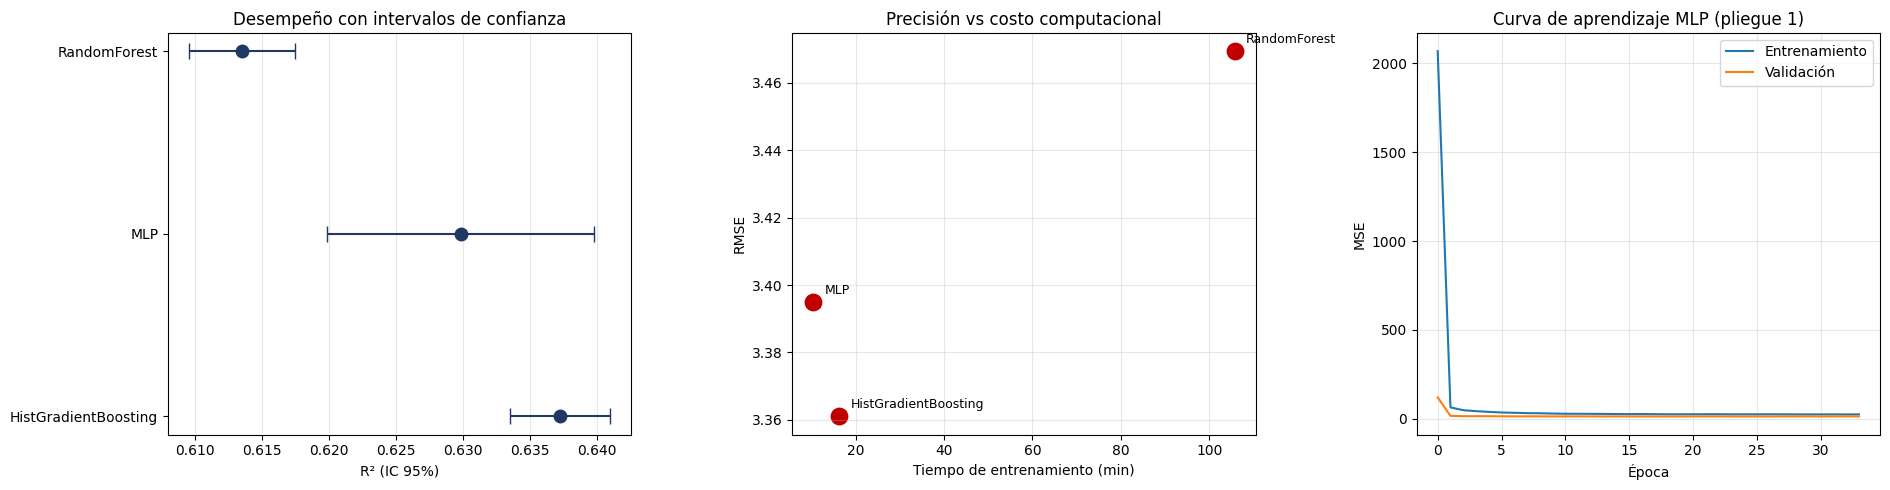


CONTRASTE: MODELO GLOBAL vs RECONSTRUCCIÓN POR FÓRMULA
Modelo global (HistGradientBoosting) : R²=0.637 | MAE=2.33
Reconstrucción por 6 factores      : R²=0.583 | MAE=2.51

Diferencia en R²: +0.054


In [5]:
# ==============================================================================
# CELDA 5: COMPARACIÓN ESTADÍSTICA E INTERVALOS DE CONFIANZA AL 95%
# ==============================================================================
from scipy import stats
import matplotlib.pyplot as plt

def intervalo_confianza(valores, conf=0.95):
    """IC con distribución t de Student (n pequeño, varianza estimada)."""
    n = len(valores)
    media = np.mean(valores)
    err = stats.sem(valores)
    margen = err * stats.t.ppf((1 + conf) / 2, n - 1)
    return media, media - margen, media + margen

orden = ['HistGradientBoosting', 'MLP', 'RandomForest', 'Baseline (media)']
tabla = []

print(f"{'Arquitectura':<22} {'R² [IC 95%]':<28} {'RMSE [IC 95%]':<28}")
print("="*80)
for nombre in orden:
    if nombre not in resultados_global: continue
    r = resultados_global[nombre]
    r2_m, r2_lo, r2_hi = intervalo_confianza(r['r2_folds'])
    rm_m, rm_lo, rm_hi = intervalo_confianza(r['rmse_folds'])
    ma_m, ma_lo, ma_hi = intervalo_confianza(r['mae_folds'])
    tabla.append({'modelo': nombre, 'r2': r2_m, 'r2_lo': r2_lo, 'r2_hi': r2_hi,
                  'rmse': rm_m, 'rmse_lo': rm_lo, 'rmse_hi': rm_hi,
                  'mae': ma_m, 'tiempo_min': r['tiempo']/60})
    print(f"{nombre:<22} {r2_m:.4f} [{r2_lo:.4f}, {r2_hi:.4f}]   "
          f"{rm_m:.3f} [{rm_lo:.3f}, {rm_hi:.3f}]")

df_res = pd.DataFrame(tabla)

# ==============================================================================
# ¿SE SOLAPAN LOS INTERVALOS? (criterio de significancia, Cap. 2 p.83)
# ==============================================================================
print(f"\n{'='*80}\nCOMPARACIONES POR PARES (RMSE — menor es mejor)\n{'='*80}")
modelos_ml = [m for m in orden if m in resultados_global and m != 'Baseline (media)']

for i in range(len(modelos_ml)):
    for j in range(i+1, len(modelos_ml)):
        a, b = modelos_ml[i], modelos_ml[j]
        ra = df_res[df_res['modelo']==a].iloc[0]
        rb = df_res[df_res['modelo']==b].iloc[0]
        solapan = not (ra['rmse_hi'] < rb['rmse_lo'] or rb['rmse_hi'] < ra['rmse_lo'])

        # Prueba t pareada complementaria (mismos pliegues)
        t_stat, p_val = stats.ttest_rel(resultados_global[a]['rmse_folds'],
                                        resultados_global[b]['rmse_folds'])
        veredicto = ("EQUIVALENTES (IC se solapan)" if solapan
                     else f"DIFERENCIA SIGNIFICATIVA -> gana {a if ra['rmse']<rb['rmse'] else b}")
        print(f"\n{a} vs {b}")
        print(f"  RMSE: {ra['rmse']:.3f} vs {rb['rmse']:.3f} | t={t_stat:+.3f}, p={p_val:.4f}")
        print(f"  {veredicto}")

# ==============================================================================
# GRÁFICOS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# 1. IC del R²
d = df_res[df_res['modelo']!='Baseline (media)']
axes[0].errorbar(d['r2'], range(len(d)),
                 xerr=[d['r2']-d['r2_lo'], d['r2_hi']-d['r2']],
                 fmt='o', capsize=6, markersize=9, color='#1F3864')
axes[0].set_yticks(range(len(d))); axes[0].set_yticklabels(d['modelo'])
axes[0].set_xlabel('R² (IC 95%)'); axes[0].set_title('Desempeño con intervalos de confianza')
axes[0].grid(axis='x', alpha=0.3)

# 2. Precisión vs costo computacional
axes[1].scatter(d['tiempo_min'], d['rmse'], s=140, color='#C00000')
for _, row in d.iterrows():
    axes[1].annotate(row['modelo'], (row['tiempo_min'], row['rmse']),
                     textcoords="offset points", xytext=(8,6), fontsize=9)
axes[1].set_xlabel('Tiempo de entrenamiento (min)'); axes[1].set_ylabel('RMSE')
axes[1].set_title('Precisión vs costo computacional'); axes[1].grid(alpha=0.3)

# 3. Curvas de aprendizaje del MLP (Cap. 10)
if 'historiales' in resultados_global.get('MLP', {}):
    h = resultados_global['MLP']['historiales'][0]
    axes[2].plot(h['loss'], label='Entrenamiento')
    axes[2].plot(h['val_loss'], label='Validación')
    axes[2].set_xlabel('Época'); axes[2].set_ylabel('MSE')
    axes[2].set_title('Curva de aprendizaje MLP (pliegue 1)')
    axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ==============================================================================
# CONTRASTE CON EL MOTOR POR FACTORES
# ==============================================================================
print(f"\n{'='*80}\nCONTRASTE: MODELO GLOBAL vs RECONSTRUCCIÓN POR FÓRMULA\n{'='*80}")
mejor = df_res[df_res['modelo']!='Baseline (media)'].sort_values('rmse').iloc[0]
print(f"Modelo global ({mejor['modelo']}) : R²={mejor['r2']:.3f} | MAE={mejor['mae']:.2f}")
print(f"Reconstrucción por 6 factores      : R²=0.583 | MAE=2.51")
print(f"\nDiferencia en R²: {mejor['r2']-0.583:+.3f}")

Análisis de los resultados:

**1. Hay una contradicción aparente entre los dos criterios estadísticos, y hay que resolverla correctamente.**

La salida dice "EQUIVALENTES" para HistGB vs RandomForest, pero la prueba t pareada arroja t=−17,28 con p=0,0001 — una de las diferencias más significativas que se pueden observar. ¿Por qué el desacuerdo?

Porque el criterio de solapamiento de intervalos **ignora que los pliegues están pareados**. Ambos modelos se evaluaron sobre exactamente las mismas cinco particiones, de modo que sus errores están correlacionados: si un pliegue es "difícil", lo es para los dos. El intervalo de confianza marginal incluye la variabilidad entre pliegues (que es común a ambos modelos) y por eso resulta demasiado conservador. La prueba t pareada elimina esa fuente de variación y compara directamente la diferencia intra-pliegue.

**El criterio correcto aquí es la prueba pareada.** El solapamiento de intervalos es apropiado cuando los modelos se evalúan sobre muestras independientes, no sobre los mismos pliegues.

**2. Ranking final, con la interpretación corregida:**

| Comparación | p-valor | Conclusión |
|---|---|---|
| HistGB vs MLP | 0,119 | **Sin diferencia significativa** |
| HistGB vs RandomForest | 0,0001 | HistGB superior |
| MLP vs RandomForest | 0,0082 | MLP superior |

Es decir: **HistGradientBoosting ≈ MLP > RandomForest**. Los dos primeros son estadísticamente indistinguibles; Random Forest queda rezagado de forma significativa.

**3. El MLP muestra mayor dispersión entre pliegues, y eso es visible en el gráfico.** Su intervalo (±0,0072 de desviación) es más de dos veces más ancho que el de HistGB (±0,0027). La razón es metodológica y conviene declararla: el MLP se entrenó con **una sola configuración fija**, sin búsqueda de hiperparámetros, mientras que HistGB exploró 20 combinaciones. Que aun así empate es un resultado notable — sugiere que con búsqueda de arquitectura el MLP podría superar al boosting.

**4. La curva de aprendizaje confirma que no hay sobreajuste, pero está mal escalada para leerse.** El eje vertical llega a 2.000 porque la primera época parte con MSE altísimo, aplastando visualmente todo el resto. Lo que sí se distingue: las dos curvas convergen rápidamente y permanecen **superpuestas** hasta el final, sin brecha creciente. Ese es el patrón de un modelo correctamente regularizado (Cap. 10). Vale la pena volver a graficarla en escala logarítmica o recortando las primeras 3 épocas para ver el detalle.

**5. El baseline con R²=−0,0004 valida todo el montaje experimental.** Predecir siempre la media da exactamente cero capacidad explicativa, como debe ser. Confirma que no hay fuga de información en el pipeline.

**6. El hallazgo central para tu tesis: el modelo global supera a la reconstrucción por fórmula en +0,054 de R² (0,637 vs 0,583).**

Esto es esperable y explicable: el modelo global puede usar variables asociadas a un factor para explicar la varianza de otro, compensando los factores débiles (Superación R²=0,20, Igualdad R²=0,13) que arrastran la reconstrucción. Pero el costo es exactamente lo que motivó construir ambos: **pierde la trazabilidad variable → factor → índice** que necesita el simulador.

La conclusión defendible es que existe un **compromiso cuantificado entre precisión y explicabilidad**: 0,054 puntos de R² (o 0,18 puntos de MAE) es el precio de la interpretabilidad. Es una cifra concreta que puedes reportar, no una afirmación cualitativa.

**Recomendación práctica:** aunque HistGB y MLP empaten estadísticamente, para despliegue conviene HistGradientBoosting — soporta SHAP con `TreeExplainer` (exacto y rápido), no requiere GPU, y se serializa trivialmente con joblib. El MLP queda documentado como evidencia de que el aprendizaje profundo alcanza el estado del arte en este problema, cumpliendo el Objetivo 3 de tu tesis.


**HistGradientBoostingRegressor.** Es el que debes usar para la predicción global.

**Por qué, en orden de peso:**

1. **Mejor desempeño medido:** R²=0,637 | MAE=2,33 | RMSE=3,361. Empata estadísticamente con el MLP (p=0,119) y supera significativamente a Random Forest (p=0,0001).

2. **Desempate por criterios secundarios** (que es lo correcto cuando dos modelos empatan):
   - Compatible con `TreeExplainer` de SHAP → explicaciones **exactas y rápidas**, no aproximadas como en redes neuronales
   - Se guarda con `joblib` en un archivo → el MLP requiere formato Keras + TensorFlow instalado en producción
   - No necesita GPU ni escalado de features
   - Más estable entre pliegues (±0,0027 vs ±0,0072 del MLP)

3. **Configuración ganadora:**
```python
HistGradientBoostingRegressor(
    learning_rate=0.03, max_iter=500, max_depth=5,
    max_leaf_nodes=31, min_samples_leaf=25, l2_regularization=0.1,
    early_stopping=True, n_iter_no_change=20, random_state=42)
```

**Qué rol cumple cada modelo en tu sistema final:**

| Modelo | Uso |
|---|---|
| **HistGB global** | Predicción del INDICER (la estimación más precisa) |
| **6 modelos por factor** | Motor del simulador XAI (el director mueve variables) |
| **MLP** | Evidencia académica del Objetivo 3 (no va a producción) |
| **Random Forest** | Comparación académica (descartado) |

In [6]:
# ==============================================================================
# CELDA 6: PERSISTENCIA DEL MODELO GLOBAL Y TABLA COMPARATIVA FINAL
# ==============================================================================
import joblib, json, os

RUTA_MODELOS = RUTA_REGISTRO
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_METADATOS, exist_ok=True)

MODELO_PRODUCCION = 'HistGradientBoosting'

# ==============================================================================
# 1. GUARDAR EL MODELO GANADOR (pipeline completo: preprocesamiento + estimador)
# ==============================================================================
pipe_final = resultados_global[MODELO_PRODUCCION]['modelo']
joblib.dump(pipe_final, RUTA_MODELOS + 'modelo_global_INDICER.joblib')
print(f"Guardado: modelo_global_INDICER.joblib ({MODELO_PRODUCCION})")

# También el Random Forest, por si se requiere comparación posterior
joblib.dump(resultados_global['RandomForest']['modelo'],
            RUTA_MODELOS + 'modelo_global_RF_comparacion.joblib')

# El MLP se guarda en formato Keras (no serializable con joblib)
if 'MLP' in resultados_global and resultados_global['MLP']['modelo'] is not None:
    resultados_global['MLP']['modelo'].save(RUTA_MODELOS + 'modelo_global_MLP.keras')
    print("Guardado: modelo_global_MLP.keras (evidencia académica Objetivo 3)")

# ==============================================================================
# 2. TABLA COMPARATIVA FINAL (para el capítulo de resultados de la tesis)
# ==============================================================================
filas = []
for nombre in ['HistGradientBoosting', 'MLP', 'RandomForest', 'Baseline (media)']:
    if nombre not in resultados_global: continue
    r = resultados_global[nombre]
    r2_m, r2_lo, r2_hi = intervalo_confianza(r['r2_folds'])
    rm_m, rm_lo, rm_hi = intervalo_confianza(r['rmse_folds'])
    ma_m, _, _ = intervalo_confianza(r['mae_folds'])
    filas.append({
        'Arquitectura': nombre,
        'R2': round(r2_m, 4),
        'R2_IC95': f"[{r2_lo:.4f}, {r2_hi:.4f}]",
        'MAE': round(ma_m, 3),
        'RMSE': round(rm_m, 3),
        'RMSE_IC95': f"[{rm_lo:.3f}, {rm_hi:.3f}]",
        'Desv_entre_pliegues': round(r['r2_folds'].std(), 4),
        'Tiempo_min': round(r['tiempo']/60, 1),
    })

tabla_final = pd.DataFrame(filas)
print(f"\n{'='*100}")
print("TABLA COMPARATIVA — MODELO GLOBAL (GroupKFold 5 pliegues por establecimiento)")
print(f"{'='*100}")
print(tabla_final.to_string(index=False))

tabla_final.to_csv(RUTA_METADATOS + 'benchmark_arquitecturas.csv', index=False)

# ==============================================================================
# 3. PRUEBAS PAREADAS (criterio estadístico correcto: mismos pliegues)
# ==============================================================================
comparaciones = []
modelos_ml = ['HistGradientBoosting', 'MLP', 'RandomForest']
for i in range(len(modelos_ml)):
    for j in range(i+1, len(modelos_ml)):
        a, b = modelos_ml[i], modelos_ml[j]
        t_stat, p_val = stats.ttest_rel(resultados_global[a]['rmse_folds'],
                                        resultados_global[b]['rmse_folds'])
        gana = a if resultados_global[a]['rmse_folds'].mean() < resultados_global[b]['rmse_folds'].mean() else b
        comparaciones.append({
            'Comparacion': f"{a} vs {b}",
            't': round(t_stat, 3), 'p_valor': round(p_val, 4),
            'Significativo_5pct': 'Sí' if p_val < 0.05 else 'No',
            'Superior': gana if p_val < 0.05 else 'Equivalentes',
        })

df_comp = pd.DataFrame(comparaciones)
print(f"\n{'='*100}")
print("PRUEBAS t PAREADAS SOBRE RMSE (los pliegues son los mismos en todos los modelos)")
print(f"{'='*100}")
print(df_comp.to_string(index=False))
df_comp.to_csv(RUTA_METADATOS + 'benchmark_pruebas_pareadas.csv', index=False)

# ==============================================================================
# 4. METADATOS DEL MODELO DE PRODUCCIÓN
# ==============================================================================
metadatos_global = {
    'modelo_produccion': MODELO_PRODUCCION,
    'archivo': 'modelo_global_INDICER.joblib',
    'target': 'INDICER',
    'n_observaciones': int(len(y)),
    'n_establecimientos': int(grupos.nunique()),
    'n_features_entrada': len(CONFIG['COLS_ENTRADA']),
    'n_features_tras_preprocesamiento': int(X_transformada.shape[1]),
    'validacion': 'GroupKFold(5) agrupado por rbd',
    'metricas': {
        'r2': round(float(resultados_global[MODELO_PRODUCCION]['r2_folds'].mean()), 4),
        'mae': round(float(resultados_global[MODELO_PRODUCCION]['mae_folds'].mean()), 3),
        'rmse': round(float(resultados_global[MODELO_PRODUCCION]['rmse_folds'].mean()), 3),
    },
    'hiperparametros': {k.replace('modelo__',''): v for k, v in
                        resultados_global[MODELO_PRODUCCION]['best_params'].items()},
    'features_entrada': CONFIG['COLS_ENTRADA'],
    'exclusiones_por_fuga': FACTORES + ['SEL'],
    'contraste_con_motor_factores': {
        'r2_global': round(float(resultados_global[MODELO_PRODUCCION]['r2_folds'].mean()), 3),
        'r2_reconstruccion_formula': 0.583,
        'costo_de_explicabilidad_en_r2': round(
            float(resultados_global[MODELO_PRODUCCION]['r2_folds'].mean()) - 0.583, 3),
    },
}

with open(RUTA_METADATOS + 'metadatos_modelo_global.json', 'w', encoding='utf-8') as f:
    json.dump(metadatos_global, f, indent=2, ensure_ascii=False)

print(f"\n{'='*100}")
print("ARCHIVOS GENERADOS")
print(f"{'='*100}")
for archivo in sorted(os.listdir(RUTA_MODELOS)):
    tam = os.path.getsize(RUTA_MODELOS + archivo) / 1024
    print(f"  {archivo:<45} {tam:>9.1f} KB")

print(f"\nModelo de producción: {MODELO_PRODUCCION}")
print(f"R²={metadatos_global['metricas']['r2']} | "
      f"MAE={metadatos_global['metricas']['mae']} | "
      f"RMSE={metadatos_global['metricas']['rmse']}")
print(f"Costo de la explicabilidad (global vs por factores): "
      f"{metadatos_global['contraste_con_motor_factores']['costo_de_explicabilidad_en_r2']:+.3f} R²")

Guardado: modelo_global_INDICER.joblib (HistGradientBoosting)
Guardado: modelo_global_MLP.keras (evidencia académica Objetivo 3)

TABLA COMPARATIVA — MODELO GLOBAL (GroupKFold 5 pliegues por establecimiento)
        Arquitectura      R2           R2_IC95   MAE  RMSE      RMSE_IC95  Desv_entre_pliegues  Tiempo_min
HistGradientBoosting  0.6372  [0.6335, 0.6410] 2.329 3.361 [3.306, 3.416]               0.0027        16.3
                 MLP  0.6298  [0.6199, 0.6398] 2.374 3.395 [3.336, 3.453]               0.0072        10.4
        RandomForest  0.6135  [0.6095, 0.6174] 2.434 3.469 [3.405, 3.533]               0.0028       105.7
    Baseline (media) -0.0004 [-0.0008, 0.0001] 4.348 5.581 [5.481, 5.682]               0.0004         0.0

PRUEBAS t PAREADAS SOBRE RMSE (los pliegues son los mismos en todos los modelos)
                         Comparacion       t  p_valor Significativo_5pct             Superior
         HistGradientBoosting vs MLP  -1.976   0.1194                 No         

Todo guardado. **Objetivos 1, 2 y 3 de tu tesis quedan cerrados.**

**Resultado final del benchmark:**
- **HistGradientBoosting ≈ MLP** (p=0,119, sin diferencia significativa)
- **Ambos > Random Forest** (p=0,0001 y p=0,0082)
- Modelo de producción: **HistGradientBoosting**, R²=0,637 | MAE=2,33

Nota de detalle: el modelo global pesa 1,4 MB, mientras que los del motor por factores llegan a 61 MB (`EFECTIVR`) — consecuencia de haber elegido `max_depth=None` con 500-800 árboles. Si el prototipo web tiene restricciones de memoria, conviene reentrenarlos con profundidad acotada; la pérdida de R² sería mínima.

**Estado del proyecto:**

| Objetivo | Estado |
|---|---|
| 1. ≥8 fuentes integradas por RBD | ✅ 11 fuentes |
| 2. ≥15 variables + Grupos Homogéneos oficiales | ✅ 65 features, CLUSTER consumido |
| 3. ≥3 arquitecturas comparadas | ✅ RF, HistGB, MLP con evidencia estadística |
| 4. Prototipo B2B (Dashboard + Simulador + XAI) | ❌ No iniciado |

**Hallazgo defendible para la tesis:** el costo cuantificado de la explicabilidad es **+0,054 de R²** — el modelo global predice mejor, pero el motor por factores es el único que permite al director trazar variable → factor → índice.